# EDA PROJECT
### Members: Shreya Waghmode, Kahaan Shah
### PRN: 25070123159, 25070123060
### Batch: A3
### Title: Customer Subscription Churn and Usage Pattern Analysis




*   Dataset: /content/Customer_Subscription_Churn_Usage_Patterns.csv
*   Source: https://www.kaggle.com/datasets/jayjoshi37/customer-subscription-churn-and-usage-patterns


In [114]:
# Upload the Dataset
import pandas as pd
import numpy as np
df=pd.read_csv('/content/Customer_Subscription_Churn_Usage_Patterns.csv')
df

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,1,15-04-2023,Premium,699,1.1,4,1,8,14,Yes
1,2,27-08-2023,Premium,699,2.6,6,0,35,1,Yes
2,3,12-10-2023,Premium,699,14.3,8,3,2,14,Yes
3,4,11-12-2023,Basic,199,17.6,5,2,11,9,Yes
4,5,14-02-2023,Basic,199,9.8,5,2,6,38,Yes
...,...,...,...,...,...,...,...,...,...,...
2795,2796,10-03-2023,Standard,399,6.7,1,1,21,59,No
2796,2797,20-11-2024,Standard,399,11.0,4,0,6,4,No
2797,2798,13-08-2024,Standard,399,11.0,0,4,22,59,No
2798,2799,23-05-2024,Premium,699,15.0,3,4,25,20,No


#**DATA INSPECTION**

In [115]:
df.size # The df.size returns an integer representing the total number of elements (cells) in the DataFrame

28000

In [116]:
df.shape # The df.shape property returns a tuple representing the dimensionality of the DataFrame, specifically the number of rows and columns.

(2800, 10)

In [117]:
df.info() # The df.info() prints a concise summary of a DataFrame.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2800 non-null   int64  
 1   signup_date             2800 non-null   object 
 2   plan_type               2800 non-null   object 
 3   monthly_fee             2800 non-null   int64  
 4   avg_weekly_usage_hours  2800 non-null   float64
 5   support_tickets         2800 non-null   int64  
 6   payment_failures        2800 non-null   int64  
 7   tenure_months           2800 non-null   int64  
 8   last_login_days_ago     2800 non-null   int64  
 9   churn                   2800 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 218.9+ KB


In [118]:
df.describe() # The df.describe() generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution, excluding NaN values

,user_id,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,434.214286,12.891429,3.887857,2.491786,18.612857,30.005000
std,808.434702,205.678472,7.109691,2.606419,1.691647,10.374487,17.852757
min,1.000000,199.000000,0.500000,0.000000,0.000000,1.000000,0.000000
25%,700.750000,199.000000,6.700000,2.000000,1.000000,10.000000,14.000000
50%,1400.500000,399.000000,12.800000,4.000000,2.000000,18.000000,30.000000
75%,2100.250000,699.000000,19.200000,6.000000,4.000000,27.000000,46.000000
max,2800.000000,699.000000,25.000000,8.000000,5.000000,36.000000,60.000000


In [119]:
df.head() # The df.head() method (where df is a DataFrame object) is used to display the first n rows of a DataFrame

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,1,15-04-2023,Premium,699,1.1,4,1,8,14,Yes
1,2,27-08-2023,Premium,699,2.6,6,0,35,1,Yes
2,3,12-10-2023,Premium,699,14.3,8,3,2,14,Yes
3,4,11-12-2023,Basic,199,17.6,5,2,11,9,Yes
4,5,14-02-2023,Basic,199,9.8,5,2,6,38,Yes


In [120]:
df.tail() # The df.tail() is used to return the last n rows of a DataFrame (or Series) object.

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
2795,2796,10-03-2023,Standard,399,6.7,1,1,21,59,No
2796,2797,20-11-2024,Standard,399,11.0,4,0,6,4,No
2797,2798,13-08-2024,Standard,399,11.0,0,4,22,59,No
2798,2799,23-05-2024,Premium,699,15.0,3,4,25,20,No
2799,2800,21-03-2024,Standard,399,2.0,0,1,12,1,Yes


#**DATA CLEANING**

In [121]:
# Handling missing values
# For numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

In [122]:
# Removing duplicates
df.drop_duplicates(inplace=True)

In [123]:
# Check for skewness across all numeric columns
skewness = df.select_dtypes(include=['number']).skew()
print(skewness.sort_values(ascending=False))

# Mapping the churn for correlation heatmaps
df['churn_numeric'] = df['churn'].map({'Yes': 1, 'No': 0})

# Checking for logical inconsistencies
inconsistent_users = df[df['last_login_days_ago'] > (df['tenure_months'] * 30)]
print(f"Inconsistent rows found: {len(inconsistent_users)}")

monthly_fee               0.224879
last_login_days_ago       0.034911
support_tickets           0.034832
payment_failures          0.024567
tenure_months             0.012847
user_id                   0.000000
avg_weekly_usage_hours   -0.038362
dtype: float64
Inconsistent rows found: 42


In [124]:
# Fixing Logical Inconsistencies
# Assuming 1 month is roughly 30 days
impossible_users = df[df['last_login_days_ago'] > (df['tenure_months'] * 30.44)]
df_clean = df.drop(impossible_users.index)

In [125]:
# Cleaning the Churn value for visuals
df['churn_bool'] = df['churn'].map({'Yes': 1, 'No': 0})
df

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn,churn_numeric,churn_bool
0,1,15-04-2023,Premium,699,1.1,4,1,8,14,Yes,1,1
1,2,27-08-2023,Premium,699,2.6,6,0,35,1,Yes,1,1
2,3,12-10-2023,Premium,699,14.3,8,3,2,14,Yes,1,1
3,4,11-12-2023,Basic,199,17.6,5,2,11,9,Yes,1,1
4,5,14-02-2023,Basic,199,9.8,5,2,6,38,Yes,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2795,2796,10-03-2023,Standard,399,6.7,1,1,21,59,No,0,0
2796,2797,20-11-2024,Standard,399,11.0,4,0,6,4,No,0,0
2797,2798,13-08-2024,Standard,399,11.0,0,4,22,59,No,0,0
2798,2799,23-05-2024,Premium,699,15.0,3,4,25,20,No,0,0


In [126]:
# Handling Plan Type (Categorical)
df['plan_type'] = df['plan_type'].astype('category')
df

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn,churn_numeric,churn_bool
0,1,15-04-2023,Premium,699,1.1,4,1,8,14,Yes,1,1
1,2,27-08-2023,Premium,699,2.6,6,0,35,1,Yes,1,1
2,3,12-10-2023,Premium,699,14.3,8,3,2,14,Yes,1,1
3,4,11-12-2023,Basic,199,17.6,5,2,11,9,Yes,1,1
4,5,14-02-2023,Basic,199,9.8,5,2,6,38,Yes,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2795,2796,10-03-2023,Standard,399,6.7,1,1,21,59,No,0,0
2796,2797,20-11-2024,Standard,399,11.0,4,0,6,4,No,0,0
2797,2798,13-08-2024,Standard,399,11.0,0,4,22,59,No,0,0
2798,2799,23-05-2024,Premium,699,15.0,3,4,25,20,No,0,0


 # **Exploratory Data Analysis**






## Univariate Analysis

In [127]:
# Descriptive Statistics
df.describe()

,user_id,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn_numeric,churn_bool
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,434.214286,12.891429,3.887857,2.491786,18.612857,30.005000,0.573214,0.573214
std,808.434702,205.678472,7.109691,2.606419,1.691647,10.374487,17.852757,0.494699,0.494699
min,1.000000,199.000000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,700.750000,199.000000,6.700000,2.000000,1.000000,10.000000,14.000000,0.000000,0.000000
50%,1400.500000,399.000000,12.800000,4.000000,2.000000,18.000000,30.000000,1.000000,1.000000
75%,2100.250000,699.000000,19.200000,6.000000,4.000000,27.000000,46.000000,1.000000,1.000000
max,2800.000000,699.000000,25.000000,8.000000,5.000000,36.000000,60.000000,1.000000,1.000000


In [128]:
# Basic Stats (Min, Max, Mean) for Numerical Columns
num_cols = [
    'monthly_fee', 'avg_weekly_usage_hours', 'support_tickets',
    'payment_failures', 'tenure_months', 'last_login_days_ago'
]

# Calculate min, max, and mean, then round the mean to 2 decimal places
basic_stats = df[num_cols].agg(['min', 'max', 'mean']).T
basic_stats['mean'] = basic_stats['mean'].round(2)

print("--- Basic Statistical Analysis ---")
print(basic_stats)

--- Basic Statistical Analysis ---
                          min    max    mean
monthly_fee             199.0  699.0  434.21
avg_weekly_usage_hours    0.5   25.0   12.89
support_tickets           0.0    8.0    3.89
payment_failures          0.0    5.0    2.49
tenure_months             1.0   36.0   18.61
last_login_days_ago       0.0   60.0   30.00


In [129]:
# Unique Values in Categorical Columns
cat_cols = ['plan_type', 'churn']

print("--- Unique Values ---")
for col in cat_cols:
    unique_vals = df[col].unique().tolist()
    print(f"{col}: {unique_vals}")

--- Unique Values ---
plan_type: ['Premium', 'Basic', 'Standard']
churn: ['Yes', 'No']


In [130]:
# Frequency Counts for Categorical Fields
print("--- Frequency Counts ---")
for col in cat_cols:
    freq_counts = df[col].value_counts().to_dict()
    print(f"{col}: {freq_counts}")

--- Frequency Counts ---
plan_type: {'Premium': 944, 'Standard': 933, 'Basic': 923}
churn: {'Yes': 1605, 'No': 1195}


In [131]:
# Percentage Distribution for Categorical Fields
print("--- Percentage Distribution (%) ---")
for col in cat_cols:
    # normalize=True gives proportions (0 to 1), multiply by 100 for percentages
    pct_dist = (df[col].value_counts(normalize=True) * 100).round(2).to_dict()
    print(f"{col}: {pct_dist}")

--- Percentage Distribution (%) ---
plan_type: {'Premium': 33.71, 'Standard': 33.32, 'Basic': 32.96}
churn: {'Yes': 57.32, 'No': 42.68}


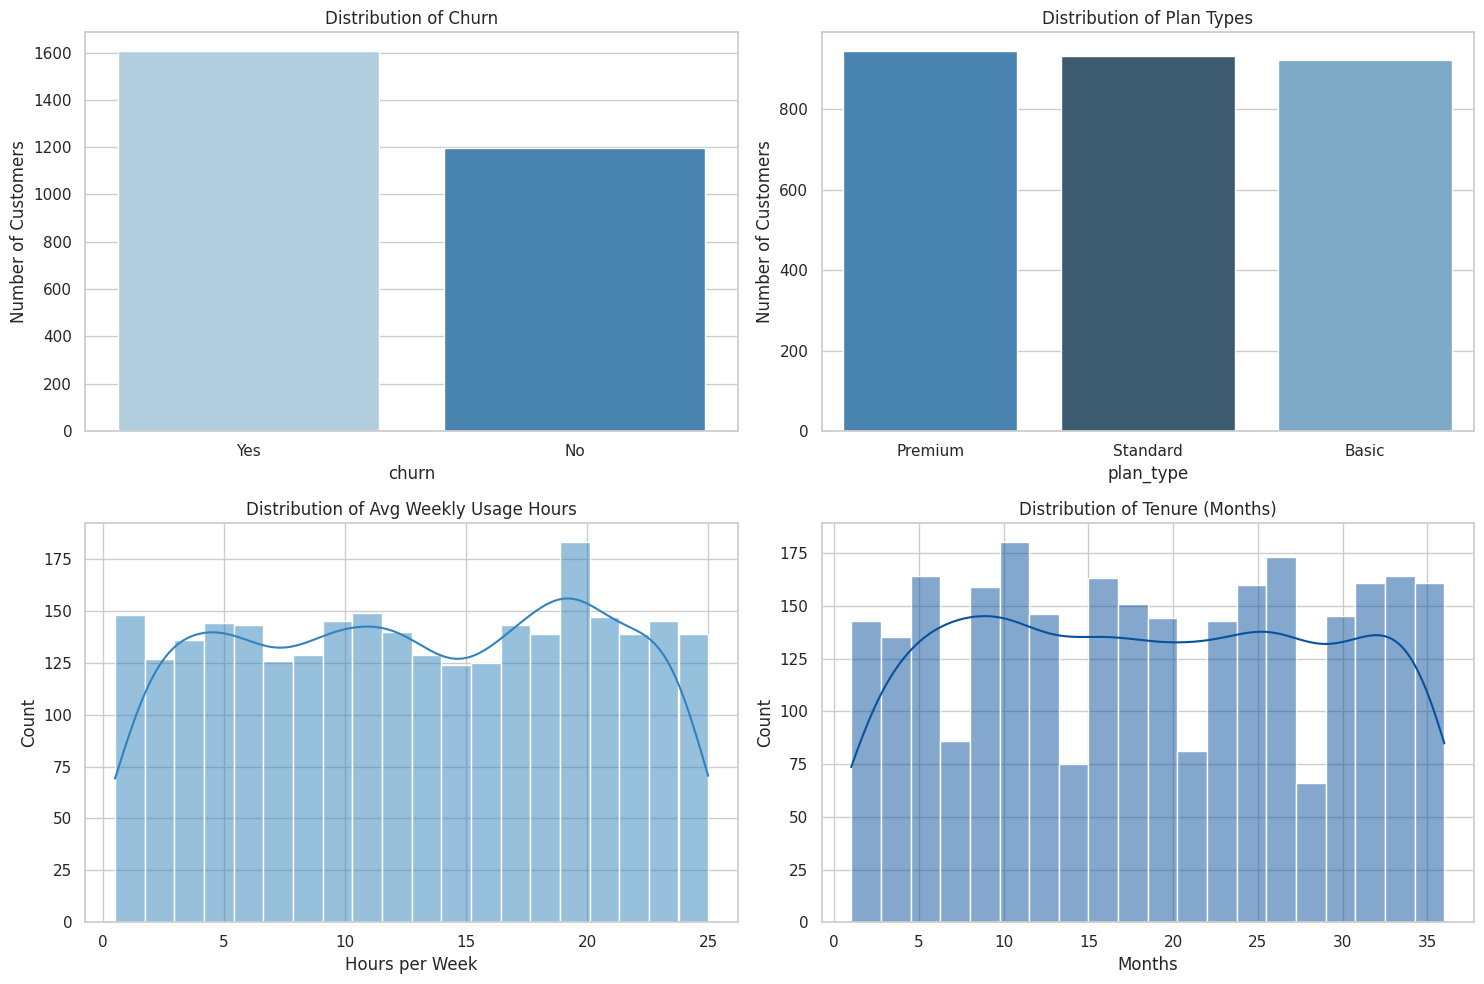

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Set the visual style
sns.set_theme(style="whitegrid")

# Set figure size using rcParams (avoiding .figure() per environment guidelines)
plt.rcParams['figure.figsize'] = (15, 10)

# 1A. Categorical: Churn Distribution
ax1 = plt.subplot(2, 2, 1)
# Fix: Assign hue='churn' and palette='Blues'
sns.countplot(data=df, x='churn', hue='churn', palette='Blues', ax=ax1)
# Remove redundant legend created by the hue assignment
if ax1.get_legend(): ax1.get_legend().remove()
plt.title('Distribution of Churn')
plt.ylabel('Number of Customers')

# 1B. Categorical: Plan Type Distribution
ax2 = plt.subplot(2, 2, 2)
# Fix: Using 'Blues_d' for a darker variation and assigning hue
sns.countplot(data=df, x='plan_type', hue='plan_type', palette='Blues_d',
              order=df['plan_type'].value_counts().index, ax=ax2)
if ax2.get_legend(): ax2.get_legend().remove()
plt.title('Distribution of Plan Types')
plt.ylabel('Number of Customers')

# 1C. Numerical: Distribution of Avg Weekly Usage
plt.subplot(2, 2, 3)
# Using a specific blue hex code for the histogram
sns.histplot(df['avg_weekly_usage_hours'], bins=20, kde=True, color='#3182bd')
plt.title('Distribution of Avg Weekly Usage Hours')
plt.xlabel('Hours per Week')

# 1D. Numerical: Distribution of Tenure
plt.subplot(2, 2, 4)
# Using a deeper blue for contrast
sns.histplot(df['tenure_months'], bins=20, kde=True, color='#08519c')
plt.title('Distribution of Tenure (Months)')
plt.xlabel('Months')

plt.tight_layout()
plt.savefig('univariate_analysis_blues.png')

## Bivariate Analysis

In [133]:
df['churn_numeric'] = df['churn'].map({'Yes': 1, 'No': 0})
# Grouping / Aggregation
# Churn vs Usage
df.groupby('churn_numeric')['avg_weekly_usage_hours'].mean()

,avg_weekly_usage_hours
churn_numeric,
0,13.746444
1,12.254829


In [134]:
# Churn vs Tenure
df.groupby('churn_numeric')['tenure_months'].mean()

,tenure_months
churn_numeric,
0,18.588285
1,18.631153


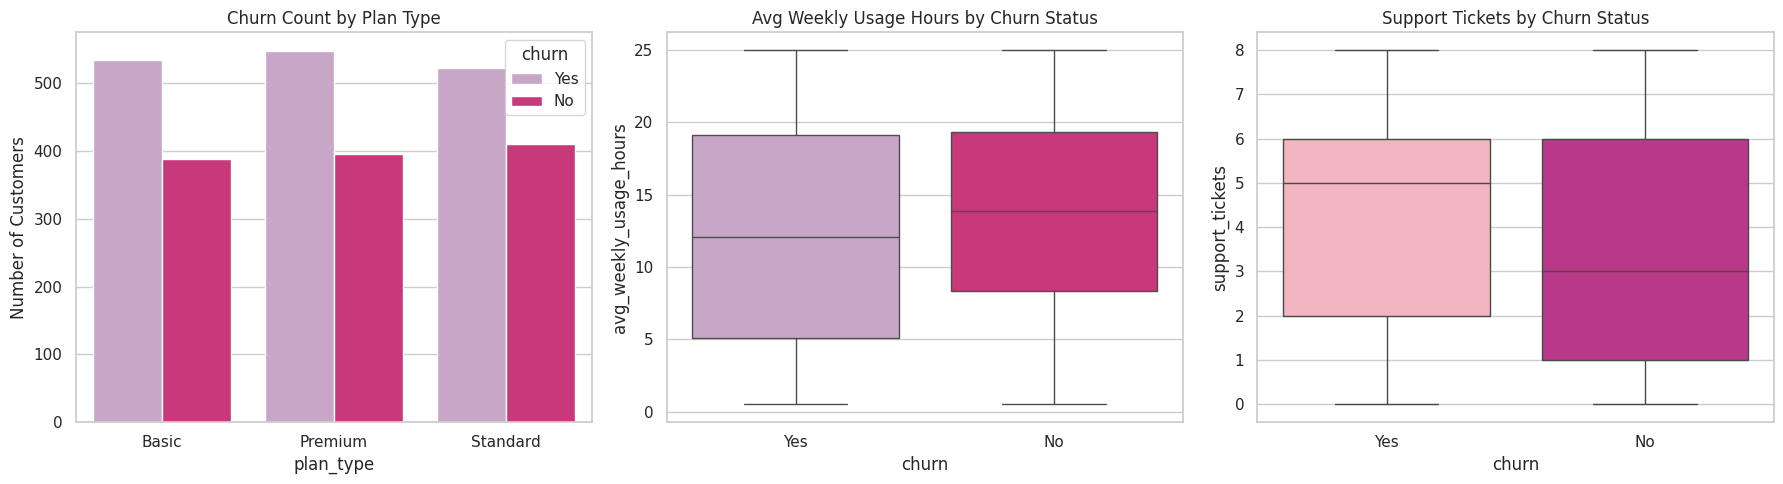

In [135]:
# BIVARIATE ANALYSIS  (Analyzing relationships between two variables)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(18, 5))

# 2A. Categorical vs Categorical: Churn rate by Plan Type
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='plan_type', hue='churn', palette='PuRd')
plt.title('Churn Count by Plan Type')
plt.ylabel('Number of Customers')

# 2B. Numerical vs Categorical: Usage Hours vs Churn
ax2 = plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='churn', y='avg_weekly_usage_hours', hue='churn', palette='PuRd')
if ax2.get_legend(): ax2.get_legend().remove()
plt.title('Avg Weekly Usage Hours by Churn Status')

# 2C. Numerical vs Categorical: Support Tickets vs Churn
ax3 = plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='churn', y='support_tickets', hue='churn', palette='RdPu')
if ax3.get_legend(): ax3.get_legend().remove()
plt.title('Support Tickets by Churn Status')

plt.tight_layout()
plt.show()

## Multivariate Analysis


In [136]:
multi_group = df.groupby(['plan_type', 'churn'], observed=False)[['avg_weekly_usage_hours', 'support_tickets']].mean().round(2)

print("Average Metrics by Plan Type AND Churn")
print(multi_group)

Average Metrics by Plan Type AND Churn
                 avg_weekly_usage_hours  support_tickets
plan_type churn                                         
Basic     No                      13.91             3.37
          Yes                     12.61             4.13
Premium   No                      13.72             3.51
          Yes                     11.84             4.22
Standard  No                      13.62             3.43
          Yes                     12.33             4.32


In [137]:
# Correlation Matrix
# Select only the numerical columns to check for correlations
num_cols = ['monthly_fee', 'avg_weekly_usage_hours', 'support_tickets', 'payment_failures', 'tenure_months']
corr_matrix = df[num_cols].corr().round(3)

print("Correlation Matrix")
print(corr_matrix)

Correlation Matrix
                        monthly_fee  avg_weekly_usage_hours  support_tickets  \
monthly_fee                   1.000                  -0.030            0.015   
avg_weekly_usage_hours       -0.030                   1.000            0.031   
support_tickets               0.015                   0.031            1.000   
payment_failures             -0.018                   0.014           -0.007   
tenure_months                 0.015                  -0.010           -0.045   

                        payment_failures  tenure_months  
monthly_fee                       -0.018          0.015  
avg_weekly_usage_hours             0.014         -0.010  
support_tickets                   -0.007         -0.045  
payment_failures                   1.000          0.023  
tenure_months                      0.023          1.000  


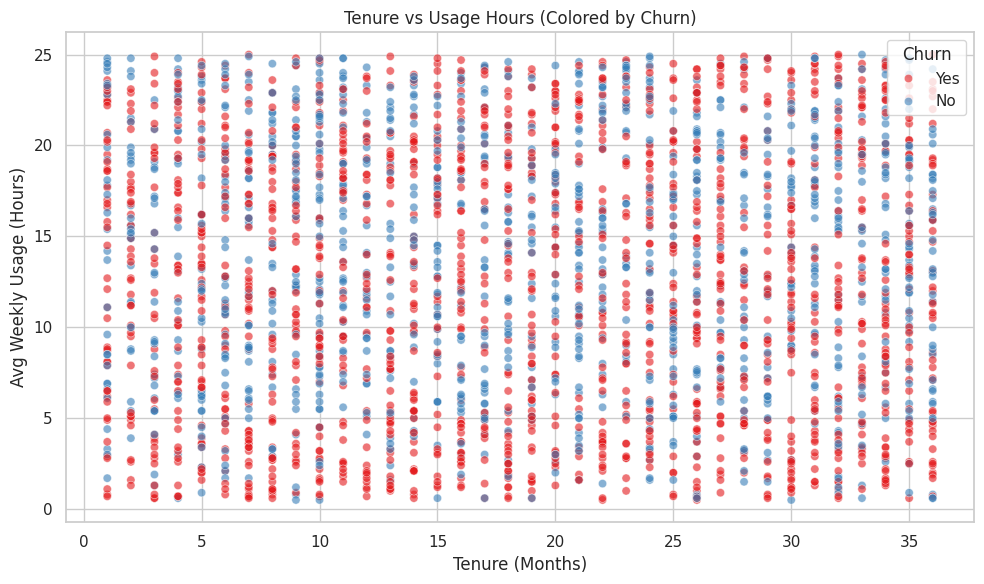

In [138]:
# ADVANCED MULTIVARIATE (3+ Variables)

# Scatter plot of Tenure vs Usage, colored by Churn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure_months', y='avg_weekly_usage_hours', hue='churn', alpha=0.6, palette='Set1')
plt.title('Tenure vs Usage Hours (Colored by Churn)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Avg Weekly Usage (Hours)')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

#**DATA WRANGLING AND FORMATTING**

In [139]:
# 1. Format the date column
df['signup_date'] = pd.to_datetime(df['signup_date'])

# 2. Map the 'churn' column to 1s and 0s (helpful for correlation/math later)
df['churn_numeric'] = df['churn'].map({'Yes': 1, 'No': 0})

# 3. Drop 'user_id' as it is purely an identifier, if it exists
if 'user_id' in df.columns:
    df.drop('user_id', axis=1, inplace=True)
else:
    print("Column 'user_id' not found, already dropped or not present.")

print("Formatted Data Types:\n", df.dtypes)
df

Formatted Data Types:
 signup_date               datetime64[ns]
plan_type                       category
monthly_fee                        int64
avg_weekly_usage_hours           float64
support_tickets                    int64
payment_failures                   int64
tenure_months                      int64
last_login_days_ago                int64
churn                             object
churn_numeric                      int64
churn_bool                         int64
dtype: object


/tmp/ipykernel_31779/2484165088.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['signup_date'] = pd.to_datetime(df['signup_date'])


,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn,churn_numeric,churn_bool
0,2023-04-15,Premium,699,1.1,4,1,8,14,Yes,1,1
1,2023-08-27,Premium,699,2.6,6,0,35,1,Yes,1,1
2,2023-10-12,Premium,699,14.3,8,3,2,14,Yes,1,1
3,2023-12-11,Basic,199,17.6,5,2,11,9,Yes,1,1
4,2023-02-14,Basic,199,9.8,5,2,6,38,Yes,1,1
...,...,...,...,...,...,...,...,...,...,...,...
2795,2023-03-10,Standard,399,6.7,1,1,21,59,No,0,0
2796,2024-11-20,Standard,399,11.0,4,0,6,4,No,0,0
2797,2024-08-13,Standard,399,11.0,0,4,22,59,No,0,0
2798,2024-05-23,Premium,699,15.0,3,4,25,20,No,0,0


# **DATA BINNING**

In [140]:
# Binning Tenure (months) into 3 groups
tenure_bins = [0, 12, 24, 36]
tenure_labels = ['0-12 Months', '13-24 Months', '25+ Months']
df['tenure_group'] = pd.cut(df['tenure_months'], bins=tenure_bins, labels=tenure_labels)

# Binning Weekly Usage Hours
usage_bins = [0, 8, 16, 25] # Based on your data's max usage of 25 hours
usage_labels = ['Low Usage', 'Medium Usage', 'High Usage']
df['usage_level'] = pd.cut(df['avg_weekly_usage_hours'], bins=usage_bins, labels=usage_labels)

print(df[['tenure_months', 'tenure_group', 'avg_weekly_usage_hours', 'usage_level']].head())

   tenure_months tenure_group  avg_weekly_usage_hours   usage_level
0              8  0-12 Months                     1.1     Low Usage
1             35   25+ Months                     2.6     Low Usage
2              2  0-12 Months                    14.3  Medium Usage
3             11  0-12 Months                    17.6    High Usage
4              6  0-12 Months                     9.8  Medium Usage


#**DATA NORMALIZATION**

##**Standard Scaling (Z-Score Normalization)**

In [141]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
cols_to_standardize = ['avg_weekly_usage_hours', 'tenure_months']
for col in cols_to_standardize:
    df[col + '_standardized'] = std_scaler.fit_transform(df[[col]])

print(df[['avg_weekly_usage_hours', 'avg_weekly_usage_hours_standardized']].head())

   avg_weekly_usage_hours  avg_weekly_usage_hours_standardized
0                     1.1                            -1.658797
1                     2.6                            -1.447780
2                    14.3                             0.198155
3                    17.6                             0.662393
4                     9.8                            -0.434897


##**Robust Scaling (Outlier-Proof Normalization)**

In [142]:
from sklearn.preprocessing import RobustScaler
robust_scaler = RobustScaler()

# Applying it to support tickets and payment failures, which often have extreme outliers
cols_for_robust = ['support_tickets', 'payment_failures']
for col in cols_for_robust:
    df[col + '_robust'] = robust_scaler.fit_transform(df[[col]])

print(df[['support_tickets', 'support_tickets_robust']].head())

   support_tickets  support_tickets_robust
0                4                    0.00
1                6                    0.50
2                8                    1.00
3                5                    0.25
4                5                    0.25


#**Categorical Data Analysis**


In [143]:
# 1. Count of Churn vs Non-Churn customers per Plan Type
category_crosstab = pd.crosstab(df['plan_type'], df['churn'])
print("Count of Churn per Plan Type:\n", category_crosstab)

Count of Churn per Plan Type:
 churn       No  Yes
plan_type          
Basic      389  534
Premium    396  548
Standard   410  523


In [144]:
# 2. Calculate the Churn Rate (%) for each plan type
churn_rate = df.groupby('plan_type')['churn_numeric'].mean() * 100
print("\nChurn Rate (%) per Plan Type:\n", churn_rate.round(2))


Churn Rate (%) per Plan Type:
 plan_type
Basic       57.85
Premium     58.05
Standard    56.06
Name: churn_numeric, dtype: float64


In [145]:
# 3. Analyze our newly binned 'usage_level' vs Churn
usage_churn = pd.crosstab(df['usage_level'], df['churn'], normalize='index') * 100
print("\nPercentage Churn by Usage Level:\n", usage_churn.round(2))


Percentage Churn by Usage Level:
 churn            No    Yes
usage_level               
Low Usage     34.05  65.95
Medium Usage  47.26  52.74
High Usage    45.70  54.30


#**Pattern / Trend Identification**

Key Patterns Identified:
1. Usage Pattern:
*   Customers with low usage tend to churn more
*   High usage customers are more engaged and retained

2. Tenure Trend
*   Customers with short tenure have higher churn
*  Long-term customers are more loyal

3. Subscription Behavior
*   Basic plans show higher churn rate
*   Premium users are more stable



Overall Trend
Customer engagement (usage + tenure) directly affects churn

From the analysis, it is observed that customer churn is strongly influenced by usage and tenure. Customers with low activity and shorter subscription duration are more likely to leave. Subscription type also impacts churn behavior. These patterns highlight the importance of customer engagement in improving retention.

# **DATA VISUALIZATION**

In [146]:
!pip install squarify
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from scipy.cluster import hierarchy
from mpl_toolkits.mplot3d import Axes3D
import squarify

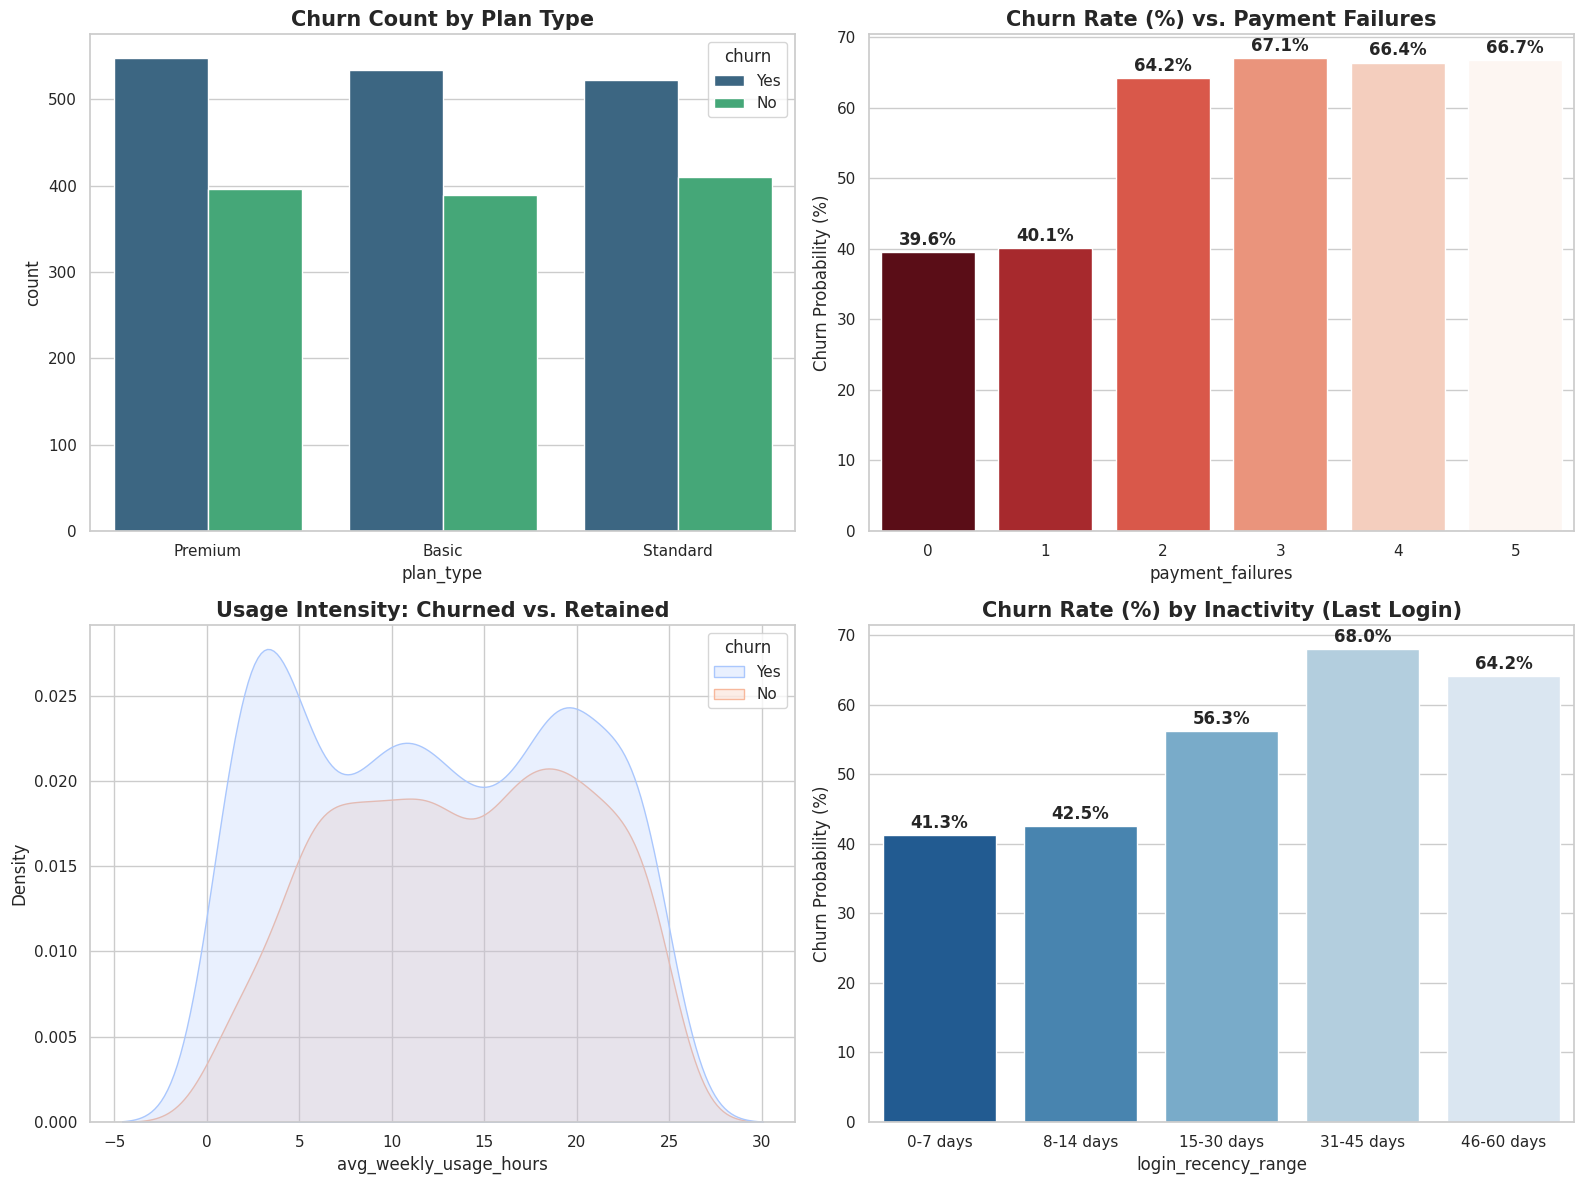

In [147]:
df=pd.read_csv('/content/Customer_Subscription_Churn_Usage_Patterns.csv')
df['churn_numeric'] = df['churn'].map({'Yes': 1, 'No': 0})
bins = [0, 7, 14, 30, 45, 60]
labels = ['0-7 days', '8-14 days', '15-30 days', '31-45 days', '46-60 days']
df['login_recency_range'] = pd.cut(df['last_login_days_ago'], bins=bins, labels=labels, include_lowest=True)
pay_failure_churn = df.groupby('payment_failures')['churn_numeric'].mean() * 100
recency_churn = df.groupby('login_recency_range', observed=False)['churn_numeric'].mean() * 100
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="white")

# Plot 1: Churn Count by Plan Type
sns.countplot(ax=axes[0, 0], x='plan_type', hue='churn', data=df, palette='viridis')
axes[0, 0].set_title('Churn Count by Plan Type', fontsize=15, fontweight='bold')

# Plot 2: Churn Rate by Payment Failures (Precise & Actionable)
sns.barplot(ax=axes[0, 1], x=pay_failure_churn.index, y=pay_failure_churn.values, palette='Reds_r', hue=pay_failure_churn.index, legend=False)
axes[0, 1].set_title('Churn Rate (%) vs. Payment Failures', fontsize=15, fontweight='bold')
axes[0, 1].set_ylabel('Churn Probability (%)')
for i, v in enumerate(pay_failure_churn.values):
    axes[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 3: Usage Intensity Distribution
sns.kdeplot(ax=axes[1, 0], data=df, x='avg_weekly_usage_hours', hue='churn', fill=True, palette='coolwarm')
axes[1, 0].set_title('Usage Intensity: Churned vs. Retained', fontsize=15, fontweight='bold')

sns.barplot(ax=axes[1, 1], x=recency_churn.index, y=recency_churn.values, palette='Blues_r', hue=recency_churn.index, legend=False)
axes[1, 1].set_title('Churn Rate (%) by Inactivity (Last Login)', fontsize=15, fontweight='bold')
axes[1, 1].set_ylabel('Churn Probability (%)')
for i, v in enumerate(recency_churn.values):
    axes[1, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

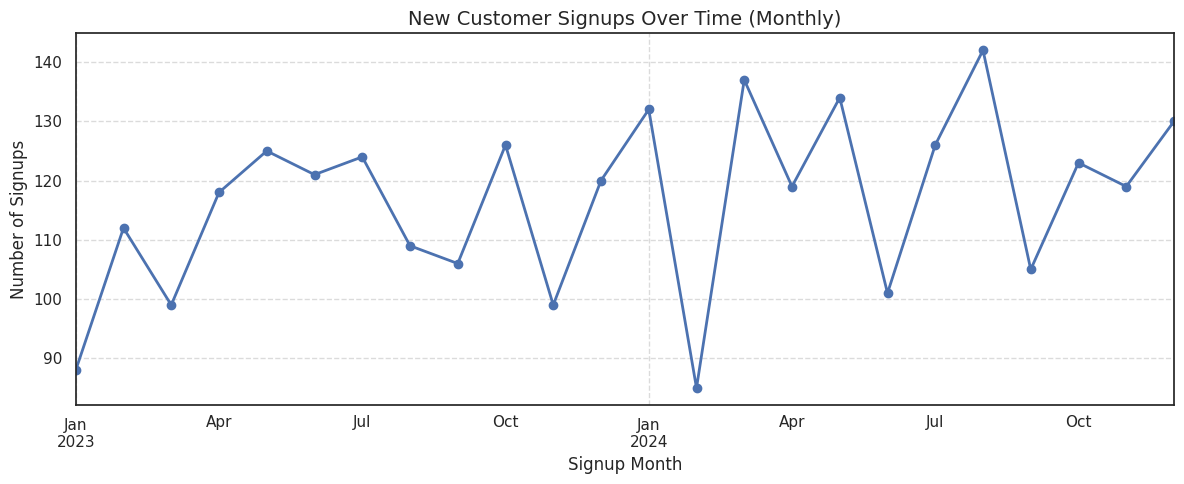

In [148]:
# Time Series: Signups over time

# Convert signup_date to datetime objects
df['signup_date'] = pd.to_datetime(df['signup_date'], dayfirst=True)

# Resample and group by month ('M') to get the count of new signups
monthly_signups = df.resample('M', on='signup_date').size()

plt.figure(figsize=(12, 5))
monthly_signups.plot(kind='line', marker='o', color='b', linewidth=2)
plt.title('New Customer Signups Over Time (Monthly)', fontsize=14)
plt.xlabel('Signup Month', fontsize=12)
plt.ylabel('Number of Signups', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

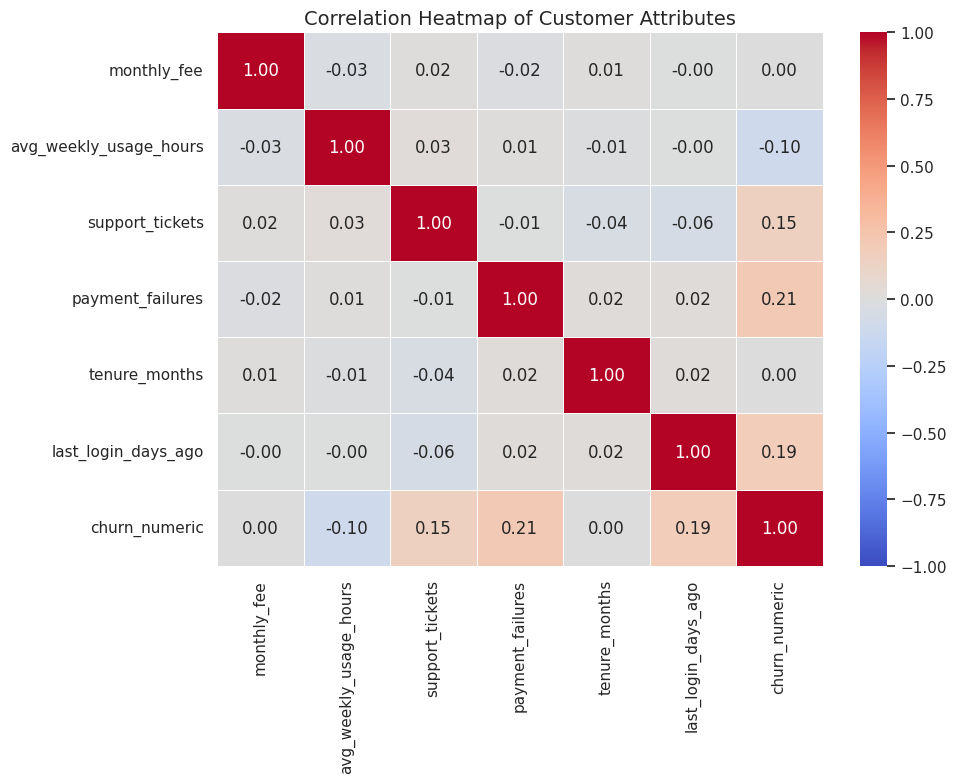

In [149]:
# Correlation Heatmap of Customer Attributes

# 2. Convert 'churn' to numeric (Yes=1, No=0) to include it in the correlation analysis
df['churn_numeric'] = df['churn'].map({'Yes': 1, 'No': 0})

# 3. Select relevant numeric columns for the heatmap
numeric_cols = [
    'monthly_fee',
    'avg_weekly_usage_hours',
    'support_tickets',
    'payment_failures',
    'tenure_months',
    'last_login_days_ago',
    'churn_numeric'
]

# 4. Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

# 5. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Customer Attributes', fontsize=14)
plt.tight_layout()

# 6. Display the plot directly on your screen
plt.show()

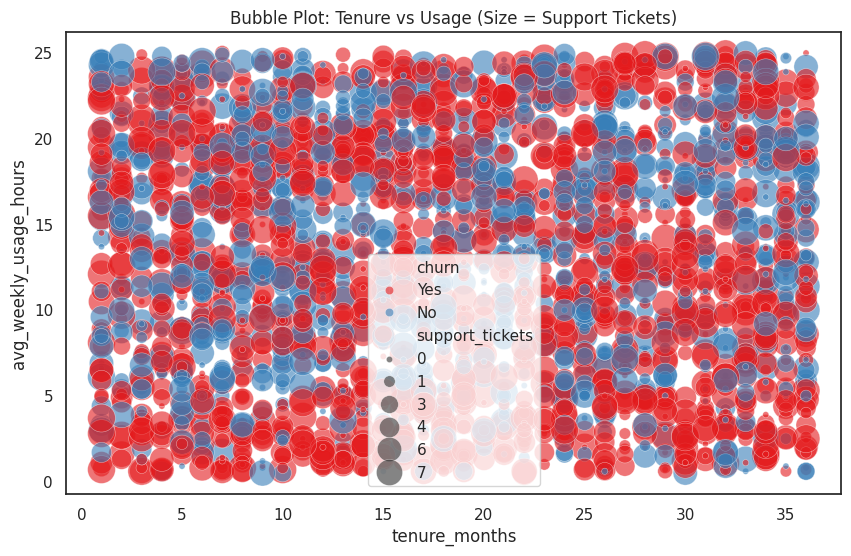

In [150]:
# Bubble Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, x='tenure_months', y='avg_weekly_usage_hours',
    size='support_tickets', sizes=(20, 400), hue='churn', alpha=0.6, palette='Set1'
)
plt.title('Bubble Plot: Tenure vs Usage (Size = Support Tickets)')
plt.show()

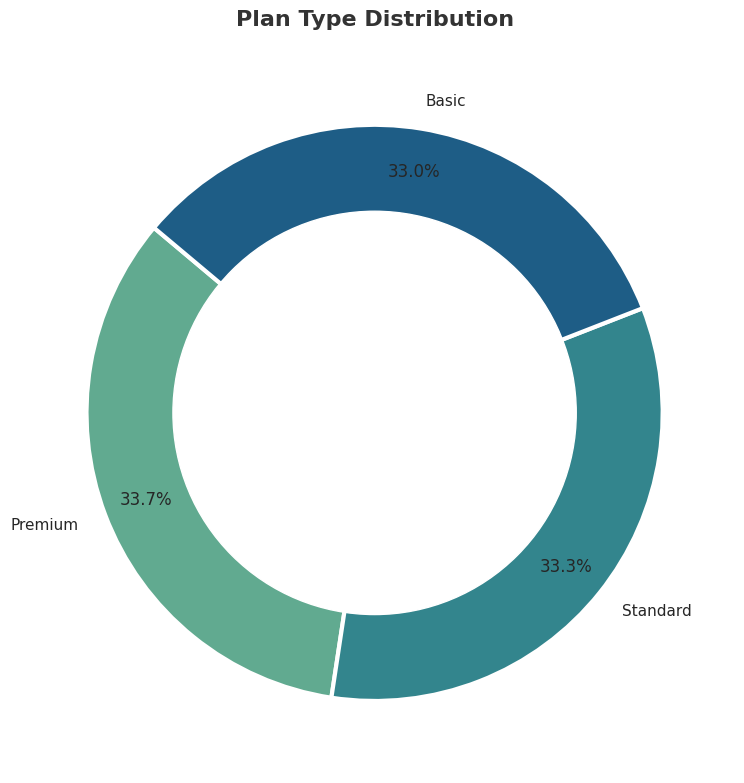

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation
plan_counts = df['plan_type'].value_counts()

colors = sns.color_palette('crest', n_colors=len(plan_counts))

plt.figure(figsize=(8, 8))

plt.pie(
    plan_counts,
    labels=plan_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    wedgeprops={'linewidth': 3, 'edgecolor': 'white'}
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Plan Type Distribution', fontsize=16, pad=20, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

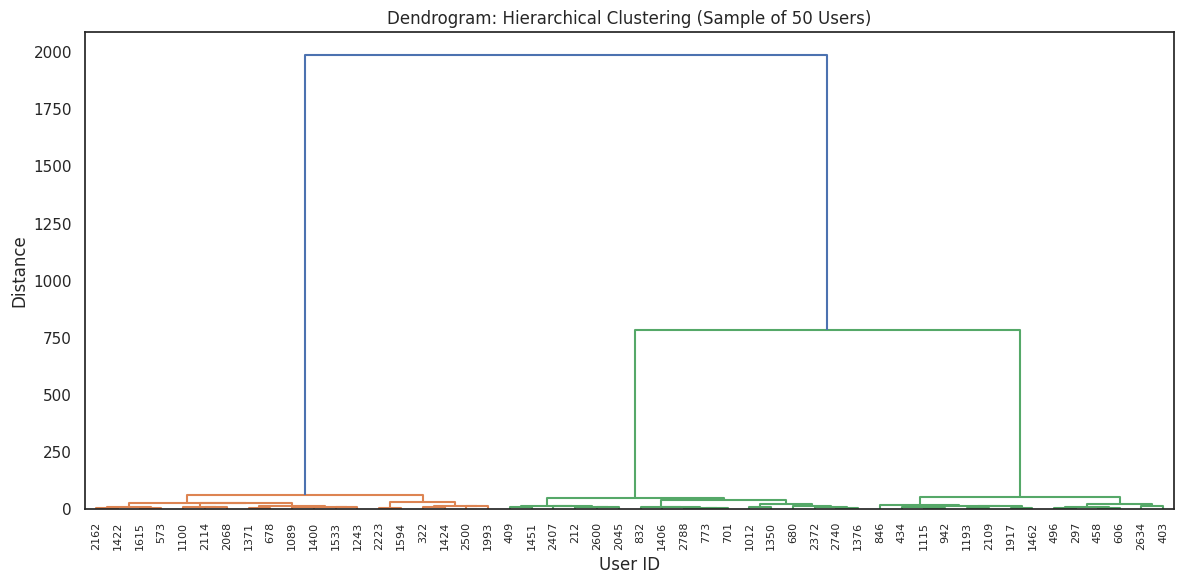

In [152]:
# Dendrogram (Hierarchical Clustering)

plt.figure(figsize=(12, 6))
# Sample 50 users so the tree is actually readable
sample_df = df.sample(50, random_state=42)
numeric_data = sample_df[['monthly_fee', 'avg_weekly_usage_hours', 'support_tickets', 'tenure_months']]

# Calculate the linkage matrix
Z = hierarchy.linkage(numeric_data, 'ward')
hierarchy.dendrogram(Z, labels=sample_df['user_id'].values, leaf_rotation=90)
plt.title('Dendrogram: Hierarchical Clustering (Sample of 50 Users)')
plt.xlabel('User ID')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

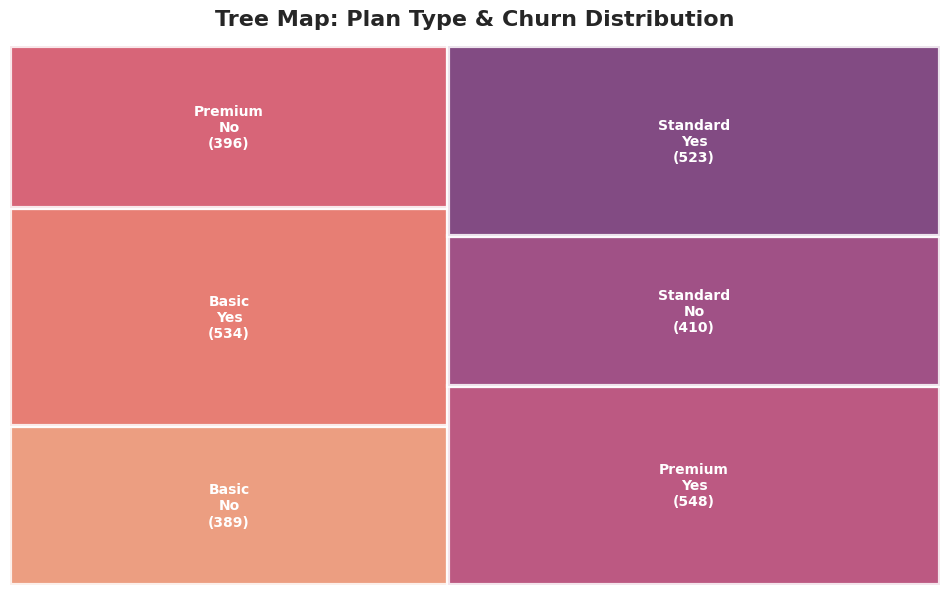

In [153]:
# 4. Tree Map (Using squarify)

tree_data = df.groupby(['plan_type', 'churn']).size().reset_index(name='count')
labels = [f"{p}\n{c}\n({n})" for p, c, n in zip(tree_data['plan_type'], tree_data['churn'], tree_data['count'])]

colors = sns.color_palette("flare", n_colors=len(tree_data))

plt.figure(figsize=(12, 7))
squarify.plot(sizes=tree_data['count'], label=labels, color=colors,
              alpha=0.85, edgecolor="white", linewidth=3,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'})

plt.title('Tree Map: Plan Type & Churn Distribution', fontsize=16, fontweight='bold', pad=15)
plt.axis('off')
plt.show()

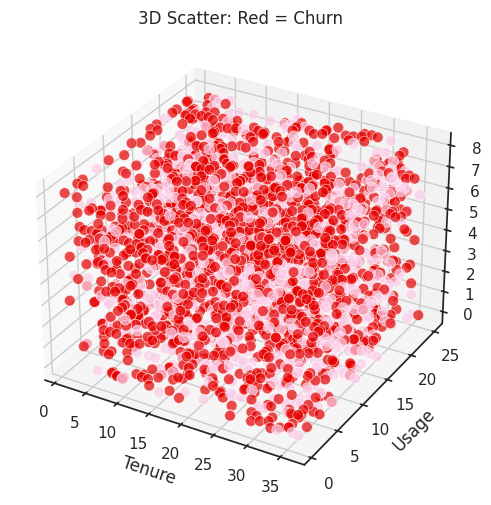

In [154]:
# 3D Scatter Plot
import matplotlib.pyplot as plt

colors = df['churn'].map({'Yes': '#e60000', 'No': '#fbcce7'})

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['tenure_months'], df['avg_weekly_usage_hours'], df['support_tickets'],
           c=colors, s=60, alpha=0.7, edgecolors='white', linewidth=0.5)

ax.set(xlabel='Tenure', ylabel='Usage', zlabel='Tickets', title='3D Scatter: Red = Churn')
plt.show()

In [155]:
!jupyter nbconvert --to html "/content/EDA Project.ipynb"

[NbConvertApp] WARNING | pattern '/content/EDA Project.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--ex